In [1]:
import pandas as pd
import numpy as np
import lifelines
import sklearn
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor

In [2]:
clinical = pd.read_csv('MMRF_patient_info.tsv', sep='\t')


print(clinical.head())

   PUBLIC_ID  D_PT_ic_day D_PT_DIDPATIENTCOM  D_PT_deathdy  D_PT_lastdy  \
0  MMRF_1014          -10                 No           NaN       1186.0   
1  MMRF_1017          -16                 No         508.0        508.0   
2  MMRF_1024          -27                Yes           NaN       2907.0   
3  MMRF_1038          -30                 No        1753.0       1753.0   
4  MMRF_1033          -29                Yes           NaN       2883.0   

                                  D_PT_PRIMARYREASON    D_PT_CAUSEOFDEATH  \
0  Patient no longer consents to participate in t...                  NaN   
1                                              Death  Disease progression   
2                                                NaN                  NaN   
3                                              Death  Disease progression   
4                                                NaN                  NaN   

  D_PT_disc_com SE_SPECIFY2 dth_specify  ...  DEMOG_BLACKORAFRICA  \
0           NaN  

In [3]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 90 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PUBLIC_ID            971 non-null    object 
 1   D_PT_ic_day          971 non-null    int64  
 2   D_PT_DIDPATIENTCOM   514 non-null    object 
 3   D_PT_deathdy         341 non-null    float64
 4   D_PT_lastdy          513 non-null    float64
 5   D_PT_PRIMARYREASON   512 non-null    object 
 6   D_PT_CAUSEOFDEATH    336 non-null    object 
 7   D_PT_disc_com        40 non-null     object 
 8   SE_SPECIFY2          143 non-null    object 
 9   dth_specify          138 non-null    object 
 10  D_PT_complete        514 non-null    float64
 11  D_PT_discont         514 non-null    float64
 12  D_PT_DISCREAS        512 non-null    float64
 13  D_PT_dthreas         336 non-null    float64
 14  dthord               138 non-null    float64
 15  D_PT_raceoth         49 non-null     obj

In [4]:
pd.unique(clinical['D_PT_race'])

array([1, 4, 2, 6, 3], dtype=int64)

In [5]:
race_counts = clinical['D_PT_race'].value_counts() #1 is white, 2 is black, 3 is Indian American, 4 is Asian and 6 is others

print(race_counts)

D_PT_race
1    742
2    161
6     49
4     18
3      1
Name: count, dtype: int64


In [6]:
pd.unique(clinical['D_PT_raceoth'])

array([nan, 'Patient Declined', 'Middle Eastern', 'Not Specified',
       'Middle Eastern Indian', 'More Than One Race', 'Unkown', 'Unknown',
       'Unknown/Declined', 'Declined', 'Honduras', 'Filipino',
       'Costa Rican', 'Declines To Answer', 'Not Available'], dtype=object)

In [7]:
rows_with_middle_eastern = clinical.loc[clinical['D_PT_raceoth'].str.contains('middle eastern', case=False, na=False)]

print(rows_with_middle_eastern)

     PUBLIC_ID  D_PT_ic_day D_PT_DIDPATIENTCOM  D_PT_deathdy  D_PT_lastdy  \
59   MMRF_1325           -7                NaN           NaN          NaN   
137  MMRF_1222           -3                 No         825.0        825.0   
599  MMRF_1980          -27                NaN           NaN          NaN   
625  MMRF_1122          -17                 No         697.0        697.0   

    D_PT_PRIMARYREASON    D_PT_CAUSEOFDEATH D_PT_disc_com SE_SPECIFY2  \
59                 NaN                  NaN           NaN         NaN   
137              Death  Disease progression           NaN         NaN   
599                NaN                  NaN           NaN         NaN   
625              Death  Disease progression           NaN         NaN   

    dth_specify  ...  DEMOG_BLACKORAFRICA  DEMOG_NATIVEHAWAIIA  DEMOG_WHITE  \
59          NaN  ...                  NaN                  NaN          NaN   
137         NaN  ...                  NaN                  NaN          NaN   
599        

In [8]:
mask = clinical['D_PT_raceoth'].str.contains('middle eastern|honduras|costa', case=False, na=False)

clinical.loc[mask, 'D_PT_race'] = clinical.loc[mask, 'D_PT_race'].replace(6, 1)


In [9]:
filipino_mask = clinical['D_PT_raceoth'].str.contains('filipino', case=False, na=False)

clinical.loc[filipino_mask, 'D_PT_race'] = clinical.loc[filipino_mask, 'D_PT_race'].replace(6, 4)

In [10]:
race_counts = clinical['D_PT_race'].value_counts() #1 is white, 2 is black, 3 is Indian American, 4 is Asian and 6 is others

print(race_counts)

D_PT_race
1    748
2    161
6     42
4     19
3      1
Name: count, dtype: int64


In [11]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 90 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PUBLIC_ID            971 non-null    object 
 1   D_PT_ic_day          971 non-null    int64  
 2   D_PT_DIDPATIENTCOM   514 non-null    object 
 3   D_PT_deathdy         341 non-null    float64
 4   D_PT_lastdy          513 non-null    float64
 5   D_PT_PRIMARYREASON   512 non-null    object 
 6   D_PT_CAUSEOFDEATH    336 non-null    object 
 7   D_PT_disc_com        40 non-null     object 
 8   SE_SPECIFY2          143 non-null    object 
 9   dth_specify          138 non-null    object 
 10  D_PT_complete        514 non-null    float64
 11  D_PT_discont         514 non-null    float64
 12  D_PT_DISCREAS        512 non-null    float64
 13  D_PT_dthreas         336 non-null    float64
 14  dthord               138 non-null    float64
 15  D_PT_raceoth         49 non-null     obj

In [12]:
pd.unique(clinical['earlydth'])

array([ 1., nan])

In [13]:
clinical['earlydth'] = clinical['earlydth'].fillna(0)

In [14]:
mapping = {
    'Stem cell, Autologous': 1,
    'Stem cell, Allogenic': 2,
    None: 0 
}

clinical['bmtx_type'] = clinical['bmtx_type'].map(mapping)


In [15]:
pd.unique(clinical['bmtx_type'])

array([ 1., nan,  2.])

In [16]:
unique_values_counts = clinical['dthord'].value_counts()

print(unique_values_counts)


dthord
9.0     34
5.0     32
1.0     23
10.0    19
7.0     11
6.0      7
4.0      5
8.0      5
2.0      1
3.0      1
Name: count, dtype: int64


In [17]:
columns_to_drop = [
    'D_PT_DIDPATIENTCOM', 'D_PT_disc_com', 'SE_SPECIFY2', 'D_PT_CAUSEOFDEATH', 'D_PT_ic_day',
    'dth_specify', 'D_PT_ic_day', 'D_PT_PRIMARYREASON', 'dth_specify', 'D_PT_discont',
    'D_PT_raceoth', 'D_PT_ethnic', 'D_PT_DIDTHEPATIENT', 'D_PT_screen', 'D_PT_deathdy',
    'D_PT_lvisit', 'D_PT_lvisitc', 'D_PT_issstage', 'D_PT_issstage_char', 'D_PT_DISCREAS', 'D_PT_dthreas',
    'DEMOG_AMERICANINDIA', 'dthord', 'D_PT_enr', 'D_PT_lvisitdy', 'D_PT_lstalive', 'D_PT_sdeathdy', 'D_PT_trtstdy', 
    'DEMOG_ASIAN', 'DEMOG_BLACKORAFRICA', 'DEMOG_NATIVEHAWAIIA', 'D_PT_ttfpdw', 'D_PT_therclass',
    'DEMOG_WHITE', 'DEMOG_OTHER', 'DEMOG_SPECIFY', 'DEMOG_DAYOFVISIT', 'sct_elig', 'D_PT_maxline', 
    'DEMOG_DAYOFBIRTH', 'fhr', 'sct1stf', 'D_PT_mmstatus', 'maintendy', 'D_PT_respdur', 'D_PT_therfstn', 
    'maintday', 'maint1stf', 'D_PT_pddy', 'D_PT_pdflag', 'mainttrt', 'sctflag', 'sctline', 'line1sct', 'sct_bresp', 'ftrttrpl',
     'D_PT_mmstatus1', 'D_PT_mmstatus2', 'DEMOG_PATIENTAGE', 'maintstdy', 'fstsctdy', 'presctst', 'prescten',
    'D_PT_mmstatus3', 'D_PT_rapd', 'D_PT_dresp', 'demog_vj_interval', 'maintflag', 'prescttrt',
    'demog_visitdy', 'demog_visit', 'DEMOG_GENDER', 'DEMOG_ETHNICITY', 'enr'
]

clinical_cleaned = clinical.drop(columns=columns_to_drop, errors='ignore')

print(clinical_cleaned.columns)

Index(['PUBLIC_ID', 'D_PT_lastdy', 'D_PT_complete', 'D_PT_race', 'D_PT_gender',
       'IMWG_Risk_Class', 'Prolif_Index', 'D_PT_age', 'D_PT_iss', 'CREATININE',
       'ecog', 'D_PT_therclassn', 'bmtx_type', 'earlydth', 'DEMOG_HEIGHT',
       'DEMOG_HEIGHTUNITOFM', 'DEMOG_WEIGHT', 'DEMOG_WEIGHTUNITOFM'],
      dtype='object')


In [18]:
pd.unique(clinical['DEMOG_HEIGHTUNITOFM'])

array(['in', 'cm'], dtype=object)

In [19]:
def convert_height_to_cm(column):
    if column['DEMOG_HEIGHTUNITOFM'].lower() == 'in':
        return column['DEMOG_HEIGHT'] * 2.54  
    return column['DEMOG_HEIGHT'] 

clinical_cleaned['DEMOG_HEIGHT'] = clinical_cleaned.apply(convert_height_to_cm, axis=1)

clinical_cleaned['DEMOG_HEIGHT'] = clinical_cleaned['DEMOG_HEIGHT'].astype('int64')

In [20]:
pd.unique(clinical_cleaned['DEMOG_HEIGHT'])

array([160, 172, 157, 180, 175, 177, 162, 167, 154, 187, 149, 165, 161,
       170, 147, 182, 190, 152, 193, 185, 166, 163, 188, 155, 145, 178,
       158, 169, 164, 156, 186, 184, 191, 159, 173, 176, 181, 183, 171,
       150, 168, 174, 243, 189, 179, 198, 202, 148, 196, 153, 151, 192,
       121, 142, 144, 146, 141], dtype=int64)

In [21]:
pd.unique(clinical['DEMOG_WEIGHTUNITOFM'])

array(['lb', 'kg'], dtype=object)

In [22]:
def convert_weight_to_kg(column):
    if column['DEMOG_WEIGHTUNITOFM'].lower() == 'lb':
        return column['DEMOG_WEIGHT'] * 0.45 
    return column['DEMOG_WEIGHT'] 

clinical_cleaned['DEMOG_WEIGHT'] = clinical_cleaned.apply(convert_weight_to_kg, axis=1)

clinical['DEMOG_WEIGHT'] = clinical_cleaned['DEMOG_WEIGHT'].astype('int64')

In [23]:
clinical_cleaned['BMI'] = clinical_cleaned['DEMOG_WEIGHT'] / (clinical_cleaned['DEMOG_HEIGHT'] / 100) ** 2

clinical_cleaned['BMI'] = clinical_cleaned['BMI'].round(1)

In [24]:
clinical_cleaned.head(40)

,PUBLIC_ID,D_PT_lastdy,D_PT_complete,D_PT_race,D_PT_gender,IMWG_Risk_Class,Prolif_Index,D_PT_age,D_PT_iss,CREATININE,ecog,D_PT_therclassn,bmtx_type,earlydth,DEMOG_HEIGHT,DEMOG_HEIGHTUNITOFM,DEMOG_WEIGHT,DEMOG_WEIGHTUNITOFM,BMI
0,MMRF_1014,1186.0,2.0,1,2,NaN,NaN,64,1.0,70.720,0.0,5,1.0,1.0,160,in,85.05,lb,33.2
1,MMRF_1017,508.0,2.0,1,1,NaN,NaN,75,1.0,79.560,1.0,3,NaN,1.0,172,in,90.45,lb,30.6
2,MMRF_1024,2907.0,1.0,1,2,NaN,1.515921,79,2.0,123.760,1.0,1,NaN,1.0,157,in,52.20,lb,21.2
3,MMRF_1038,1753.0,2.0,1,1,NaN,2.048673,69,3.0,97.240,1.0,3,NaN,0.0,180,in,100.35,lb,31.0
4,MMRF_1033,2883.0,1.0,4,1,0.0,1.565463,64,1.0,79.560,0.0,3,NaN,1.0,175,in,71.55,lb,23.4
5,MMRF_1007,327.0,2.0,1,1,NaN,NaN,78,3.0,176.800,1.0,1,NaN,1.0,175,in,75.60,lb,24.7
6,MMRF_1052,314.0,2.0,1,1,NaN,NaN,74,2.0,97.240,0.0,1,NaN,1.0,180,in,100.35,lb,31.0
7,MMRF_1082,830.0,2.0,2,1,0.0,NaN,47,2.0,159.120,1.0,1,1.0,0.0,177,in,113.40,lb,36.2
8,MMRF_1094,2728.0,2.0,1,2,NaN,NaN,59,2.0,88.400,0.0,1,1.0,0.0,162,in,53.10,lb,20.2
9,MMRF_1093,2391.0,2.0,2,2,NaN,NaN,66,1.0,53.040,1.0,3,NaN,0.0,162,in,82.35,lb,31.4


In [25]:
columns_to_drop = ['DEMOG_WEIGHT', 'DEMOG_HEIGHT', 'DEMOG_WEIGHTUNITOFM', 'DEMOG_HEIGHTUNITOFM']
clinical_cleaned = clinical_cleaned.drop(columns=columns_to_drop)

In [26]:
clinical_cleaned.head(10)

,PUBLIC_ID,D_PT_lastdy,D_PT_complete,D_PT_race,D_PT_gender,IMWG_Risk_Class,Prolif_Index,D_PT_age,D_PT_iss,CREATININE,ecog,D_PT_therclassn,bmtx_type,earlydth,BMI
0,MMRF_1014,1186.0,2.0,1,2,NaN,NaN,64,1.0,70.72,0.0,5,1.0,1.0,33.2
1,MMRF_1017,508.0,2.0,1,1,NaN,NaN,75,1.0,79.56,1.0,3,NaN,1.0,30.6
2,MMRF_1024,2907.0,1.0,1,2,NaN,1.515921,79,2.0,123.76,1.0,1,NaN,1.0,21.2
3,MMRF_1038,1753.0,2.0,1,1,NaN,2.048673,69,3.0,97.24,1.0,3,NaN,0.0,31.0
4,MMRF_1033,2883.0,1.0,4,1,0.0,1.565463,64,1.0,79.56,0.0,3,NaN,1.0,23.4
5,MMRF_1007,327.0,2.0,1,1,NaN,NaN,78,3.0,176.80,1.0,1,NaN,1.0,24.7
6,MMRF_1052,314.0,2.0,1,1,NaN,NaN,74,2.0,97.24,0.0,1,NaN,1.0,31.0
7,MMRF_1082,830.0,2.0,2,1,0.0,NaN,47,2.0,159.12,1.0,1,1.0,0.0,36.2
8,MMRF_1094,2728.0,2.0,1,2,NaN,NaN,59,2.0,88.40,0.0,1,1.0,0.0,20.2
9,MMRF_1093,2391.0,2.0,2,2,NaN,NaN,66,1.0,53.04,1.0,3,NaN,0.0,31.4


In [27]:
clinical_cleaned = clinical_cleaned.dropna(subset=['D_PT_complete'])

In [28]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        514 non-null    object 
 1   D_PT_lastdy      513 non-null    float64
 2   D_PT_complete    514 non-null    float64
 3   D_PT_race        514 non-null    int64  
 4   D_PT_gender      514 non-null    int64  
 5   IMWG_Risk_Class  333 non-null    float64
 6   Prolif_Index     305 non-null    float64
 7   D_PT_age         514 non-null    int64  
 8   D_PT_iss         501 non-null    float64
 9   CREATININE       512 non-null    float64
 10  ecog             439 non-null    float64
 11  D_PT_therclassn  514 non-null    int64  
 12  bmtx_type        181 non-null    float64
 13  earlydth         514 non-null    float64
 14  BMI              514 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 64.2+ KB


In [29]:
survival_data = clinical_cleaned[['D_PT_lastdy', 'D_PT_complete', 'D_PT_age', 
                          'D_PT_gender', 'CREATININE', 
                          'ecog', 'BMI']]

In [30]:
survival_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   D_PT_lastdy    513 non-null    float64
 1   D_PT_complete  514 non-null    float64
 2   D_PT_age       514 non-null    int64  
 3   D_PT_gender    514 non-null    int64  
 4   CREATININE     512 non-null    float64
 5   ecog           439 non-null    float64
 6   BMI            514 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 32.1 KB


In [31]:
survival_data.head(10)

,D_PT_lastdy,D_PT_complete,D_PT_age,D_PT_gender,CREATININE,ecog,BMI
0,1186.0,2.0,64,2,70.72,0.0,33.2
1,508.0,2.0,75,1,79.56,1.0,30.6
2,2907.0,1.0,79,2,123.76,1.0,21.2
3,1753.0,2.0,69,1,97.24,1.0,31.0
4,2883.0,1.0,64,1,79.56,0.0,23.4
5,327.0,2.0,78,1,176.80,1.0,24.7
6,314.0,2.0,74,1,97.24,0.0,31.0
7,830.0,2.0,47,1,159.12,1.0,36.2
8,2728.0,2.0,59,2,88.40,0.0,20.2
9,2391.0,2.0,66,2,53.04,1.0,31.4


In [32]:
pd.unique(survival_data['D_PT_complete'])

array([2., 1.])

In [33]:
survival_data = survival_data.copy()survival_data.loc[:, 'duration'] = survival_data['D_PT_lastdy']
survival_data.loc[:, 'event'] = survival_data['D_PT_complete'].apply(lambda x: 2 if x == 'event_occurred' else 1)

survival_data = survival_data.dropna()


C:\Users\Katya\AppData\Local\Temp\ipykernel_4544\833959652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survival_data.loc[:, 'duration'] = survival_data['D_PT_lastdy']
C:\Users\Katya\AppData\Local\Temp\ipykernel_4544\833959652.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survival_data.loc[:, 'event'] = survival_data['D_PT_complete'].apply(lambda x: 2 if x == 'event_occurred' else 1)


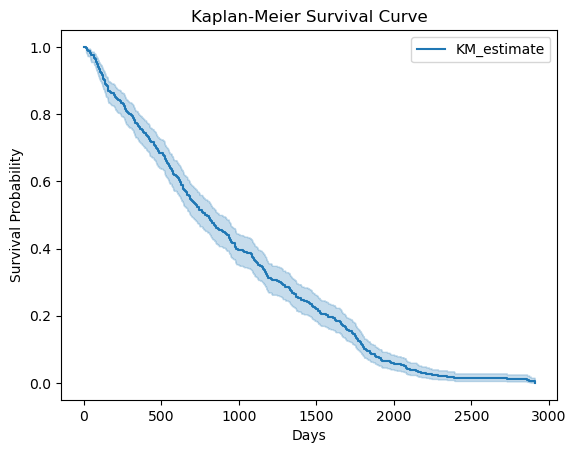

In [34]:
kmf = KaplanMeierFitter()
kmf.fit(durations=survival_data['duration'], event_observed=survival_data['event'])
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.show()


<lifelines.CoxPHFitter: fitted with 436 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 436
number of events observed = 436
   partial log-likelihood = -2204.96
         time fit was run = 2024-08-22 11:51:49 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
D_PT_age     0.00      1.00      0.00           -0.01            0.01                0.99                1.01
D_PT_gender -0.23      0.79      0.10           -0.43           -0.03                0.65                0.97
CREATININE   0.00      1.00      0.00            0.00            0.00                1.00                1.00
ecog         0.22      1.24      0.06            0.10            0.33                1.10                1.39
BMI         -0.00      1.00      0.01           -0.02            0.02                0.98                1.02

             cmp to     z      p  -log2(p)
covariate                                 
D_PT_age       0.00  0.38   0.70      0.50
D_PT_gender    0.00 -2.26   0.02      5.39
CREATININE     0.00  2.82 <0.005      7.68
ecog           0.00  3.63 <0.005     11.78
BMI            0.00 -0.06   0.95      0.07
---
Concordance = 0.57
Partial AIC = 4419.92
log-likelihood ratio test = 25.70 on 5 df
-log2(p) of ll-ratio test = 13.26

<Axes: xlabel='log(HR) (95% CI)'>

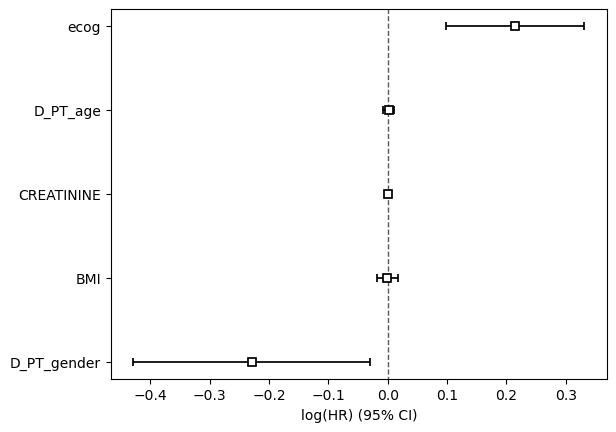

In [35]:
cph = CoxPHFitter()
cph.fit(survival_data[['duration', 'event', 'D_PT_age', 'D_PT_gender','CREATININE', 'ecog', 'BMI']], 
        duration_col='duration', event_col='event')
cph.print_summary()
cph.plot()

In [36]:
c_index = cph.concordance_index_
print(f"Concordance Index (C-index): {c_index}")

Concordance Index (C-index): 0.5747816363559644


In [37]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        514 non-null    object 
 1   D_PT_lastdy      513 non-null    float64
 2   D_PT_complete    514 non-null    float64
 3   D_PT_race        514 non-null    int64  
 4   D_PT_gender      514 non-null    int64  
 5   IMWG_Risk_Class  333 non-null    float64
 6   Prolif_Index     305 non-null    float64
 7   D_PT_age         514 non-null    int64  
 8   D_PT_iss         501 non-null    float64
 9   CREATININE       512 non-null    float64
 10  ecog             439 non-null    float64
 11  D_PT_therclassn  514 non-null    int64  
 12  bmtx_type        181 non-null    float64
 13  earlydth         514 non-null    float64
 14  BMI              514 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 64.2+ KB


In [38]:
pd.unique(clinical_cleaned['D_PT_complete']) 

array([2., 1.])

In [39]:
clinical_cleaned['bmtx_type'] = clinical_cleaned['bmtx_type'].fillna(0)

In [40]:
clinical_cleaned.head(10)

,PUBLIC_ID,D_PT_lastdy,D_PT_complete,D_PT_race,D_PT_gender,IMWG_Risk_Class,Prolif_Index,D_PT_age,D_PT_iss,CREATININE,ecog,D_PT_therclassn,bmtx_type,earlydth,BMI
0,MMRF_1014,1186.0,2.0,1,2,NaN,NaN,64,1.0,70.72,0.0,5,1.0,1.0,33.2
1,MMRF_1017,508.0,2.0,1,1,NaN,NaN,75,1.0,79.56,1.0,3,0.0,1.0,30.6
2,MMRF_1024,2907.0,1.0,1,2,NaN,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2
3,MMRF_1038,1753.0,2.0,1,1,NaN,2.048673,69,3.0,97.24,1.0,3,0.0,0.0,31.0
4,MMRF_1033,2883.0,1.0,4,1,0.0,1.565463,64,1.0,79.56,0.0,3,0.0,1.0,23.4
5,MMRF_1007,327.0,2.0,1,1,NaN,NaN,78,3.0,176.80,1.0,1,0.0,1.0,24.7
6,MMRF_1052,314.0,2.0,1,1,NaN,NaN,74,2.0,97.24,0.0,1,0.0,1.0,31.0
7,MMRF_1082,830.0,2.0,2,1,0.0,NaN,47,2.0,159.12,1.0,1,1.0,0.0,36.2
8,MMRF_1094,2728.0,2.0,1,2,NaN,NaN,59,2.0,88.40,0.0,1,1.0,0.0,20.2
9,MMRF_1093,2391.0,2.0,2,2,NaN,NaN,66,1.0,53.04,1.0,3,0.0,0.0,31.4


In [41]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        514 non-null    object 
 1   D_PT_lastdy      513 non-null    float64
 2   D_PT_complete    514 non-null    float64
 3   D_PT_race        514 non-null    int64  
 4   D_PT_gender      514 non-null    int64  
 5   IMWG_Risk_Class  333 non-null    float64
 6   Prolif_Index     305 non-null    float64
 7   D_PT_age         514 non-null    int64  
 8   D_PT_iss         501 non-null    float64
 9   CREATININE       512 non-null    float64
 10  ecog             439 non-null    float64
 11  D_PT_therclassn  514 non-null    int64  
 12  bmtx_type        514 non-null    float64
 13  earlydth         514 non-null    float64
 14  BMI              514 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 64.2+ KB


In [42]:
pd.unique(clinical_cleaned['PUBLIC_ID']) 

array(['MMRF_1014', 'MMRF_1017', 'MMRF_1024', 'MMRF_1038', 'MMRF_1033',
       'MMRF_1007', 'MMRF_1052', 'MMRF_1082', 'MMRF_1094', 'MMRF_1093',
       'MMRF_1129', 'MMRF_1137', 'MMRF_1132', 'MMRF_1193', 'MMRF_1277',
       'MMRF_1285', 'MMRF_1359', 'MMRF_1401', 'MMRF_1410', 'MMRF_1598',
       'MMRF_1670', 'MMRF_1695', 'MMRF_1838', 'MMRF_2214', 'MMRF_2230',
       'MMRF_2258', 'MMRF_2442', 'MMRF_2546', 'MMRF_1021', 'MMRF_1030',
       'MMRF_1032', 'MMRF_1079', 'MMRF_1099', 'MMRF_1177', 'MMRF_1208',
       'MMRF_1194', 'MMRF_1205', 'MMRF_1221', 'MMRF_1230', 'MMRF_1257',
       'MMRF_1286', 'MMRF_1433', 'MMRF_1461', 'MMRF_1485', 'MMRF_1497',
       'MMRF_1489', 'MMRF_1491', 'MMRF_1537', 'MMRF_1565', 'MMRF_1573',
       'MMRF_1625', 'MMRF_1759', 'MMRF_1758', 'MMRF_1801', 'MMRF_1807',
       'MMRF_1819', 'MMRF_1936', 'MMRF_2061', 'MMRF_1755', 'MMRF_2152',
       'MMRF_2172', 'MMRF_2291', 'MMRF_2310', 'MMRF_2506', 'MMRF_2548',
       'MMRF_2554', 'MMRF_2574', 'MMRF_2596', 'MMRF_2605', 'MMRF

In [43]:
clinical_cleaned['PUBLIC_ID'] = clinical_cleaned['PUBLIC_ID'].str.replace('MMRF_', '', regex=False)

In [44]:
pd.unique(clinical_cleaned['PUBLIC_ID']) 

array(['1014', '1017', '1024', '1038', '1033', '1007', '1052', '1082',
       '1094', '1093', '1129', '1137', '1132', '1193', '1277', '1285',
       '1359', '1401', '1410', '1598', '1670', '1695', '1838', '2214',
       '2230', '2258', '2442', '2546', '1021', '1030', '1032', '1079',
       '1099', '1177', '1208', '1194', '1205', '1221', '1230', '1257',
       '1286', '1433', '1461', '1485', '1497', '1489', '1491', '1537',
       '1565', '1573', '1625', '1759', '1758', '1801', '1807', '1819',
       '1936', '2061', '1755', '2152', '2172', '2291', '2310', '2506',
       '2548', '2554', '2574', '2596', '2605', '1222', '1264', '1570',
       '1586', '1034', '1029', '1039', '1055', '1124', '1166', '1209',
       '1333', '1342', '1721', '1970', '2057', '2454', '2480', '1031',
       '1018', '1041', '1016', '1049', '1084', '1101', '1151', '1179',
       '1212', '1224', '1231', '1232', '1244', '1252', '1267', '1275',
       '1089', '1387', '1389', '1391', '1450', '1454', '1502', '1513',
      

In [45]:
clinical_cleaned = clinical_cleaned.drop(['D_PT_lastdy', 'D_PT_complete'], axis=1)

In [46]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        514 non-null    object 
 1   D_PT_race        514 non-null    int64  
 2   D_PT_gender      514 non-null    int64  
 3   IMWG_Risk_Class  333 non-null    float64
 4   Prolif_Index     305 non-null    float64
 5   D_PT_age         514 non-null    int64  
 6   D_PT_iss         501 non-null    float64
 7   CREATININE       512 non-null    float64
 8   ecog             439 non-null    float64
 9   D_PT_therclassn  514 non-null    int64  
 10  bmtx_type        514 non-null    float64
 11  earlydth         514 non-null    float64
 12  BMI              514 non-null    float64
dtypes: float64(8), int64(4), object(1)
memory usage: 56.2+ KB


In [47]:
imputer = SimpleImputer(strategy='median')  

columns_to_impute = ['IMWG_Risk_Class', 'Prolif_Index', 'ecog', 'bmtx_type']
clinical_cleaned[columns_to_impute] = imputer.fit_transform(clinical_cleaned[columns_to_impute])

In [48]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 970
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        514 non-null    object 
 1   D_PT_race        514 non-null    int64  
 2   D_PT_gender      514 non-null    int64  
 3   IMWG_Risk_Class  514 non-null    float64
 4   Prolif_Index     514 non-null    float64
 5   D_PT_age         514 non-null    int64  
 6   D_PT_iss         501 non-null    float64
 7   CREATININE       512 non-null    float64
 8   ecog             514 non-null    float64
 9   D_PT_therclassn  514 non-null    int64  
 10  bmtx_type        514 non-null    float64
 11  earlydth         514 non-null    float64
 12  BMI              514 non-null    float64
dtypes: float64(8), int64(4), object(1)
memory usage: 56.2+ KB


In [49]:
clinical_cleaned = clinical_cleaned.dropna()

In [50]:
clinical_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 970
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        499 non-null    object 
 1   D_PT_race        499 non-null    int64  
 2   D_PT_gender      499 non-null    int64  
 3   IMWG_Risk_Class  499 non-null    float64
 4   Prolif_Index     499 non-null    float64
 5   D_PT_age         499 non-null    int64  
 6   D_PT_iss         499 non-null    float64
 7   CREATININE       499 non-null    float64
 8   ecog             499 non-null    float64
 9   D_PT_therclassn  499 non-null    int64  
 10  bmtx_type        499 non-null    float64
 11  earlydth         499 non-null    float64
 12  BMI              499 non-null    float64
dtypes: float64(8), int64(4), object(1)
memory usage: 54.6+ KB


In [51]:
mutations = pd.read_csv('combined_variants.tsv', sep='\t', low_memory=False)


print(mutations.head())

                    SAMPLE CHROM        POS           ID REF ALT  COSMIC  \
0  MMRF_1016_1_BM_CD138pos  chr1    3432013  rs755588843   C   T   False   
1  MMRF_1016_1_BM_CD138pos  chr1   94000926            .   A   G   False   
2  MMRF_1016_1_BM_CD138pos  chr1  152355177            .   C   G   False   
3  MMRF_1016_1_BM_CD138pos  chr2   21141897            .   A   T   False   
4  MMRF_1016_1_BM_CD138pos  chr2   43225151            .  GC  TA   False   

   COSMIC_NC  DBSNPv152  GNOMAD_EXOME  ...  ANN[*].CDS_POS  ANN[*].CDS_LEN  \
0      False       True          True  ...            3569            3831   
1      False      False         False  ...            6389            6822   
2      False      False         False  ...            2609            7176   
3      False      False         False  ...            4430            5805   
4      False      False         False  ...             652            1485   

   ANN[*].AA_POS  ANN[*].AA_LEN  ANN[*].DISTANCE  ANN[*].ERRORS  LOF[*].GE

C:\Users\Katya\AppData\Local\Temp\ipykernel_4544\2573101669.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv('combined_variants.tsv', sep='\t')


In [52]:
mutations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99755 entries, 0 to 99754
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SAMPLE            99755 non-null  object 
 1   CHROM             99755 non-null  object 
 2   POS               99755 non-null  int64  
 3   ID                99755 non-null  object 
 4   REF               99755 non-null  object 
 5   ALT               99755 non-null  object 
 6   COSMIC            99755 non-null  bool   
 7   COSMIC_NC         99755 non-null  bool   
 8   DBSNPv152         99755 non-null  bool   
 9   GNOMAD_EXOME      99755 non-null  bool   
 10  GNOMAD_GENOME     99755 non-null  bool   
 11  CLINVAR           99755 non-null  bool   
 12  CC                99755 non-null  int64  
 13  MUTECT2           99755 non-null  bool   
 14  STRELKA2          99755 non-null  bool   
 15  VARDICT           99755 non-null  bool   
 16  OCTOPUS           99755 non-null  bool  

In [53]:

columns_to_remove = [
    'COSMIC', 'COSMIC_NC', 'DBSNPv152', 'GNOMAD_EXOME', 'GNOMAD_GENOME', 'CLINVAR', 
    'MUTECT2', 'STRELKA2', 'VARDICT', 'OCTOPUS', 
    'LANCET', 'CC', 
    'GEN[1].AD[0]', 'GEN[1].AD[1]', 'GEN[1].AR', 'GEN[1].DP', 
    'ANN[*].FEATURE', 'ANN[*].FEATUREID', 'ANN[*].BIOTYPE', 'ANN[*].RANK', 
    'ANN[*].HGVS_C', 'ANN[*].HGVS_P', 'ANN[*].CDNA_POS', 'ANN[*].CDNA_LEN', 
    'ANN[*].CDS_POS', 'ANN[*].CDS_LEN', 'ANN[*].AA_POS', 'ANN[*].AA_LEN', 'ANN[*].DISTANCE', 
    'ANN[*].ERRORS', 'LOF[*].GENE', 'LOF[*].GENEID', 'LOF[*].NUMTR', 'LOF[*].PERC', 
    'ANN[*].EFFECT', 'RNA_REF_COUNT', 'RNA_ALT_COUNT', 'RNA_ALT_FREQ', 'ID', 'ANN[*].ALLELE', 'ANN[*].GENE', 'ANN[*].GENEID', 'REF', 'ALT'
]

mutations.drop(columns=columns_to_remove, inplace=True)

print(mutations.columns)


Index(['SAMPLE', 'CHROM', 'POS', 'GEN[0].AD[0]', 'GEN[0].AD[1]', 'GEN[0].AR',
       'GEN[0].DP', 'ANN[*].IMPACT'],
      dtype='object')


In [54]:

unique_samples = pd.unique(mutations['SAMPLE'])
print(unique_samples)

['MMRF_1016_1_BM_CD138pos' 'MMRF_1020_3_BM_CD138pos'
 'MMRF_1021_1_BM_CD138pos' ... 'MMRF_2946_1_BM_CD138pos'
 'MMRF_2947_1_BM_CD138pos' 'MMRF_2952_1_BM_CD138pos']


In [55]:
mutations.head(100)

,SAMPLE,CHROM,POS,GEN[0].AD[0],GEN[0].AD[1],GEN[0].AR,GEN[0].DP,ANN[*].IMPACT
0,MMRF_1016_1_BM_CD138pos,chr1,3432013,44,0,0.0,44,MODERATE
1,MMRF_1016_1_BM_CD138pos,chr1,94000926,85,0,0.0,85,MODERATE
2,MMRF_1016_1_BM_CD138pos,chr1,152355177,210,0,0.0,210,MODERATE
3,MMRF_1016_1_BM_CD138pos,chr2,21141897,147,0,0.0,147,MODERATE
4,MMRF_1016_1_BM_CD138pos,chr2,43225151,160,0,0.0,160,HIGH
...,...,...,...,...,...,...,...,...
95,MMRF_1020_3_BM_CD138pos,chr3,135179901,79,0,0.0,79,MODERATE
96,MMRF_1020_3_BM_CD138pos,chr3,142311659,143,0,0.0,143,MODERATE
97,MMRF_1020_3_BM_CD138pos,chr4,73491905,68,0,0.0,68,MODERATE
98,MMRF_1020_3_BM_CD138pos,chr4,112581736,48,0,0.0,48,MODERATE


In [56]:
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('MMRF_', '', regex=True)
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('_CD138pos', '', regex=True)
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('_BM', '', regex=True)
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('_1', '', regex=True)
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('_2', '', regex=True)
mutations['SAMPLE'] = mutations['SAMPLE'].str.replace('_3', '', regex=True)


In [57]:
mutations.head(300)

,SAMPLE,CHROM,POS,GEN[0].AD[0],GEN[0].AD[1],GEN[0].AR,GEN[0].DP,ANN[*].IMPACT
0,1016,chr1,3432013,44,0,0.0,44,MODERATE
1,1016,chr1,94000926,85,0,0.0,85,MODERATE
2,1016,chr1,152355177,210,0,0.0,210,MODERATE
3,1016,chr2,21141897,147,0,0.0,147,MODERATE
4,1016,chr2,43225151,160,0,0.0,160,HIGH
...,...,...,...,...,...,...,...,...
295,1024,chr8,24400244,261,0,0.0,261,MODERATE
296,1024,chr8,41724553,74,0,0.0,74,MODERATE
297,1024,chr10,23267211,45,0,0.0,45,MODERATE
298,1024,chr10,82358850,60,0,0.0,60,MODERATE


In [58]:
pd.unique(mutations['ANN[*].IMPACT'])

array(['MODERATE', 'HIGH'], dtype=object)

In [59]:
mutations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99755 entries, 0 to 99754
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SAMPLE         99755 non-null  object 
 1   CHROM          99755 non-null  object 
 2   POS            99755 non-null  int64  
 3   GEN[0].AD[0]   99755 non-null  int64  
 4   GEN[0].AD[1]   99755 non-null  int64  
 5   GEN[0].AR      99755 non-null  float64
 6   GEN[0].DP      99755 non-null  int64  
 7   ANN[*].IMPACT  99755 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 6.1+ MB


In [60]:
mapping = {
    'MODERATE': 1,
    'HIGH': 2
}

mutations['ANN[*].IMPACT'] = mutations['ANN[*].IMPACT'].map(mapping)

In [61]:
mutations['CHROM'] = mutations['CHROM'].str.replace('chr', '', regex=True)

In [62]:
mutations['SAMPLE'] = mutations['SAMPLE'].str.strip().astype(str)
clinical_cleaned['PUBLIC_ID'] = clinical_cleaned['PUBLIC_ID'].str.strip().astype(str)

In [63]:
merged_df = pd.merge(clinical_cleaned, mutations, left_on='PUBLIC_ID', right_on='SAMPLE', how='inner')

print(merged_df.head())

  PUBLIC_ID  D_PT_race  D_PT_gender  IMWG_Risk_Class  Prolif_Index  D_PT_age  \
0      1024          1            2              1.0      1.515921        79   
1      1024          1            2              1.0      1.515921        79   
2      1024          1            2              1.0      1.515921        79   
3      1024          1            2              1.0      1.515921        79   
4      1024          1            2              1.0      1.515921        79   

   D_PT_iss  CREATININE  ecog  D_PT_therclassn  ...  earlydth   BMI  SAMPLE  \
0       2.0      123.76   1.0                1  ...       1.0  21.2    1024   
1       2.0      123.76   1.0                1  ...       1.0  21.2    1024   
2       2.0      123.76   1.0                1  ...       1.0  21.2    1024   
3       2.0      123.76   1.0                1  ...       1.0  21.2    1024   
4       2.0      123.76   1.0                1  ...       1.0  21.2    1024   

  CHROM        POS  GEN[0].AD[0]  GEN[0].AD[

In [64]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38756 entries, 0 to 38755
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        38756 non-null  object 
 1   D_PT_race        38756 non-null  int64  
 2   D_PT_gender      38756 non-null  int64  
 3   IMWG_Risk_Class  38756 non-null  float64
 4   Prolif_Index     38756 non-null  float64
 5   D_PT_age         38756 non-null  int64  
 6   D_PT_iss         38756 non-null  float64
 7   CREATININE       38756 non-null  float64
 8   ecog             38756 non-null  float64
 9   D_PT_therclassn  38756 non-null  int64  
 10  bmtx_type        38756 non-null  float64
 11  earlydth         38756 non-null  float64
 12  BMI              38756 non-null  float64
 13  SAMPLE           38756 non-null  object 
 14  CHROM            38756 non-null  object 
 15  POS              38756 non-null  int64  
 16  GEN[0].AD[0]     38756 non-null  int64  
 17  GEN[0].AD[1]

In [65]:
merged_df = merged_df.drop(columns=['SAMPLE'])

In [66]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38756 entries, 0 to 38755
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        38756 non-null  object 
 1   D_PT_race        38756 non-null  int64  
 2   D_PT_gender      38756 non-null  int64  
 3   IMWG_Risk_Class  38756 non-null  float64
 4   Prolif_Index     38756 non-null  float64
 5   D_PT_age         38756 non-null  int64  
 6   D_PT_iss         38756 non-null  float64
 7   CREATININE       38756 non-null  float64
 8   ecog             38756 non-null  float64
 9   D_PT_therclassn  38756 non-null  int64  
 10  bmtx_type        38756 non-null  float64
 11  earlydth         38756 non-null  float64
 12  BMI              38756 non-null  float64
 13  CHROM            38756 non-null  object 
 14  POS              38756 non-null  int64  
 15  GEN[0].AD[0]     38756 non-null  int64  
 16  GEN[0].AD[1]     38756 non-null  int64  
 17  GEN[0].AR   

In [67]:
pd.unique(merged_df['CHROM'])

array(['1', '2', '3', '5', '6', '7', '8', '10', '11', '12', '14', '16',
       '17', '18', '19', '20', '22', '4', '9', '13', '15', 'X', '21', 'Y'],
      dtype=object)

In [68]:
mapping = {
    'Y': 23,
    'X': 24,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6': 6,
    '7': 7,
    '8': 8,
    '9': 9,
    '10': 10,
    '11': 11,
    '12': 12,
    '13': 13,
    '14': 14,
    '15': 15,
    '16': 16,
    '17': 17,
    '18': 18,
    '19': 19,
    '20': 20,
    '21': 21,
    '22': 22
}

merged_df['CHROM'] = merged_df['CHROM'].map(mapping)

In [69]:
pd.unique(merged_df['CHROM'])

array([ 1,  2,  3,  5,  6,  7,  8, 10, 11, 12, 14, 16, 17, 18, 19, 20, 22,
        4,  9, 13, 15, 24, 21, 23], dtype=int64)

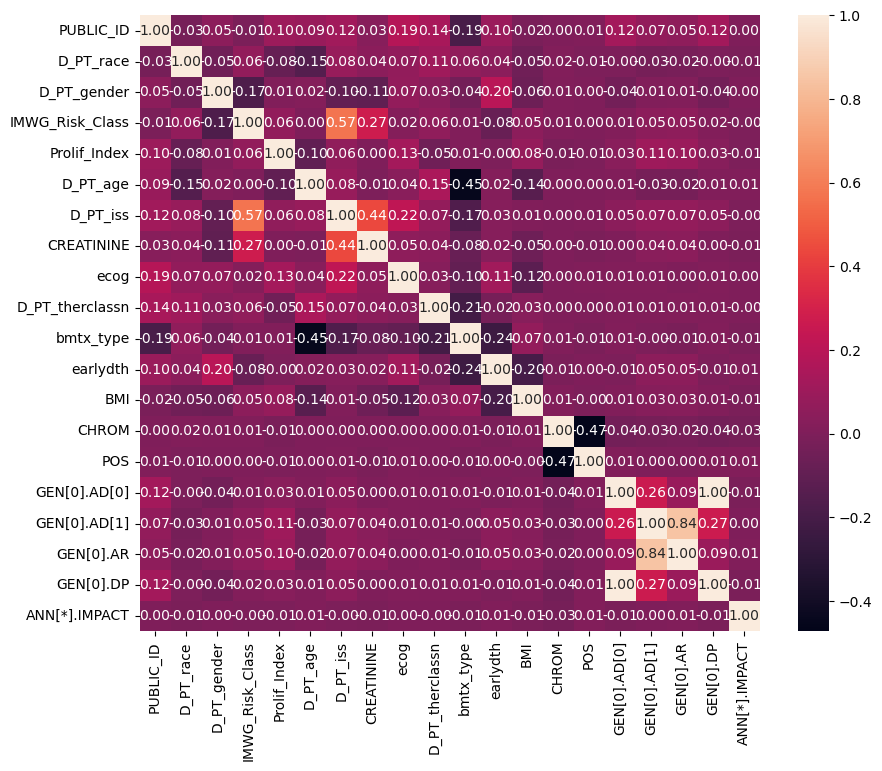

In [70]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(merged_df.corr(), annot=True, fmt=".2f")
plt.show()

In [71]:
merged_df.head()

,PUBLIC_ID,D_PT_race,D_PT_gender,IMWG_Risk_Class,Prolif_Index,D_PT_age,D_PT_iss,CREATININE,ecog,D_PT_therclassn,bmtx_type,earlydth,BMI,CHROM,POS,GEN[0].AD[0],GEN[0].AD[1],GEN[0].AR,GEN[0].DP,ANN[*].IMPACT
0,1024,1,2,1.0,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2,1,225842412,442,0,0.0,442,1
1,1024,1,2,1.0,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2,1,228318991,54,0,0.0,54,1
2,1024,1,2,1.0,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2,1,240330683,117,0,0.0,119,1
3,1024,1,2,1.0,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2,1,240330703,130,0,0.0,130,1
4,1024,1,2,1.0,1.515921,79,2.0,123.76,1.0,1,0.0,1.0,21.2,1,240330745,136,0,0.0,137,1


In [72]:
pd.unique(merged_df['ANN[*].IMPACT'])

array([1, 2], dtype=int64)

Explained Variance Ratio: [1.31457050e-01 1.10659620e-01 9.06781387e-02 8.67028980e-02
 8.15550322e-02 6.55856846e-02 6.34359604e-02 5.80439485e-02
 5.53475464e-02 4.97575684e-02 4.29186167e-02 4.10406773e-02
 3.90603406e-02 2.91990908e-02 2.79651337e-02 1.89143025e-02
 7.66181442e-03 1.65771906e-05]
Cumulative Explained Variance: [0.13145705 0.24211667 0.33279481 0.41949771 0.50105274 0.56663842
 0.63007438 0.68811833 0.74346588 0.79322345 0.83614206 0.87718274
 0.91624308 0.94544217 0.97340731 0.99232161 0.99998342 1.        ]


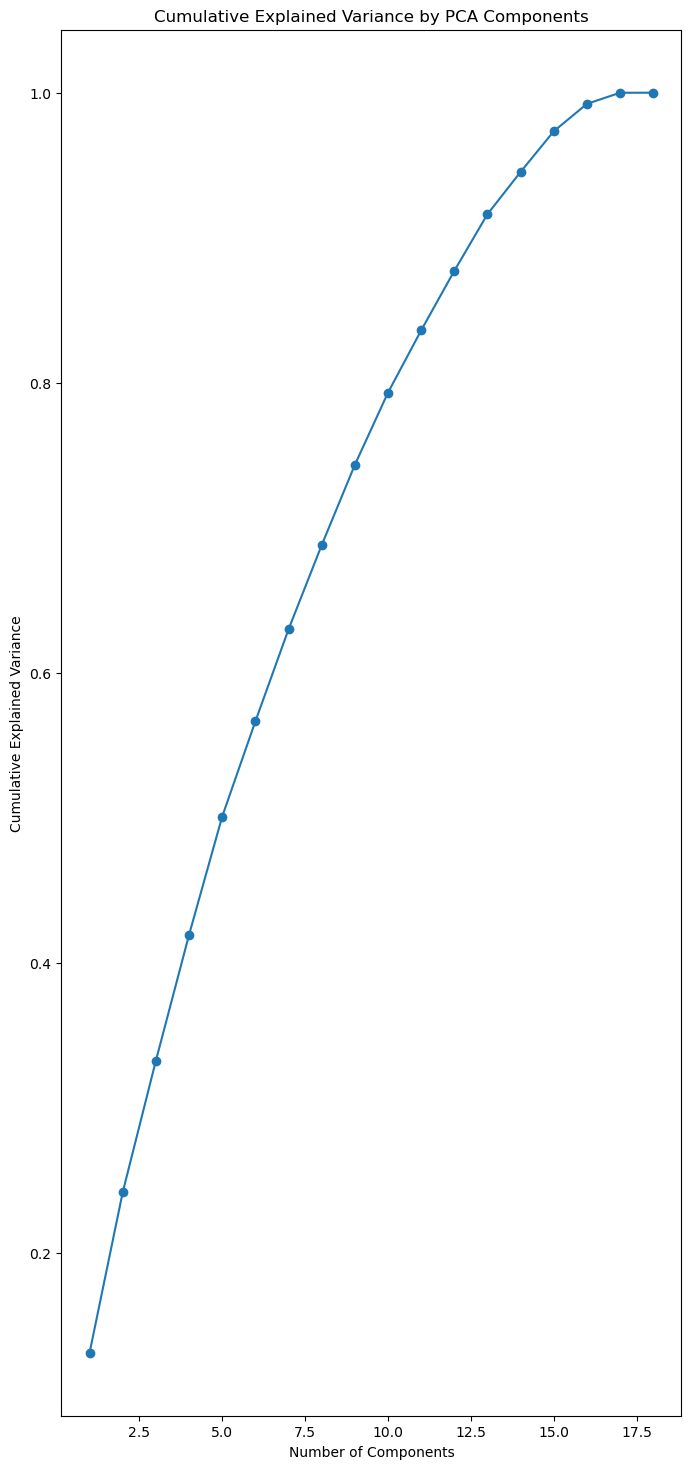

In [73]:
features = ['D_PT_race', 'D_PT_gender', 'IMWG_Risk_Class', 'Prolif_Index', 'D_PT_age', 'D_PT_iss', 
            'CREATININE', 'ecog', 'D_PT_therclassn', 'bmtx_type', 'BMI', 'POS', 'GEN[0].AD[0]', 
            'GEN[0].AD[1]', 'GEN[0].AR', 'GEN[0].DP', 'ANN[*].IMPACT', 'CHROM']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged_df[features])

pca = PCA(n_components=18) 
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative Explained Variance: {pca.explained_variance_ratio_.cumsum()}")

plt.figure(figsize=(8, 18))
plt.plot(range(1, 19), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [74]:
X = merged_df[['CHROM', 'ANN[*].IMPACT']]
y = merged_df['earlydth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=1))

importances = model.feature_importances_
feature_names = ['CHROM', 'ANN[*].IMPACT']
print("Feature importances:")
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00      4016
         1.0       0.65      1.00      0.79      7611

    accuracy                           0.65     11627
   macro avg       0.83      0.50      0.40     11627
weighted avg       0.77      0.65      0.52     11627

Feature importances:
CHROM: 0.9505
ANN[*].IMPACT: 0.0495


In [75]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38756 entries, 0 to 38755
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PUBLIC_ID        38756 non-null  object 
 1   D_PT_race        38756 non-null  int64  
 2   D_PT_gender      38756 non-null  int64  
 3   IMWG_Risk_Class  38756 non-null  float64
 4   Prolif_Index     38756 non-null  float64
 5   D_PT_age         38756 non-null  int64  
 6   D_PT_iss         38756 non-null  float64
 7   CREATININE       38756 non-null  float64
 8   ecog             38756 non-null  float64
 9   D_PT_therclassn  38756 non-null  int64  
 10  bmtx_type        38756 non-null  float64
 11  earlydth         38756 non-null  float64
 12  BMI              38756 non-null  float64
 13  CHROM            38756 non-null  int64  
 14  POS              38756 non-null  int64  
 15  GEN[0].AD[0]     38756 non-null  int64  
 16  GEN[0].AD[1]     38756 non-null  int64  
 17  GEN[0].AR   

In [78]:
X = merged_df.drop('earlydth', axis=1)
y = merged_df['earlydth']

categorical_cols = ['D_PT_gender', 'bmtx_type', 'D_PT_race', 'CHROM', 'D_PT_therclassn']
numeric_cols = [col for col in X.columns if col not in categorical_cols + ['PUBLIC_ID', 'POS']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)

pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', lasso)])

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', random_forest)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_lasso.fit(X_train, y_train)
y_pred_lasso = pipeline_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print("Mean Squared Error for Lasso:", mse_lasso)

lasso_coefficients = pipeline_lasso.named_steps['regressor'].coef_
all_feature_names = np.concatenate([
    numeric_cols,
    pipeline_lasso.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
])
feature_coefficients = dict(zip(all_feature_names, lasso_coefficients))

significant_features = [feature for feature, coef in feature_coefficients.items() if abs(coef) > 0.1 or abs(coef) < -0.1]
print("Significant Features:", significant_features)

X_transformed = pipeline_lasso.named_steps['preprocessor'].transform(X)
significant_indices = [np.where(all_feature_names == feature)[0][0] for feature in significant_features]
X_significant = X_transformed[:, significant_indices]

lasso_significant = LassoCV(cv=5, random_state=42)
lasso_significant.fit(X_significant, y)
y_pred_significant = lasso_significant.predict(X_significant)
mse_significant = mean_squared_error(y, y_pred_significant)
print("Mean Squared Error with Significant Features:", mse_significant)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv_scores = cross_val_score(pipeline_lasso, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Cross-Validated MSE for Lasso:", -np.mean(lasso_cv_scores))

rf_cv_scores = cross_val_score(pipeline_rf, X, y, cv=kfold, scoring='neg_mean_squared_error')
print("Cross-Validated MSE for Random Forest:", -np.mean(rf_cv_scores))

Mean Squared Error for Lasso: 0.1904355363524893
Significant Features: ['D_PT_gender_1', 'bmtx_type_0.0', 'bmtx_type_2.0', 'D_PT_race_4', 'D_PT_race_6', 'D_PT_therclassn_5', 'D_PT_therclassn_9']
Mean Squared Error with Significant Features: 0.20282406208336404
Cross-Validated MSE for Lasso: 0.19730019806363142
Cross-Validated MSE for Random Forest: 1.624210678098861e-05
